In [1]:
pip install numpy pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/2026-03.csv")
df["remain_seat_cnt"] = df["remain_seat_cnt"].fillna(0)
df.head()

,time,plate_no,route_id,remain_seat_cnt,station_id,station_seq,extra
0,2026-03-10 06:30:00,경기79바1683,232000090,39.0,232000540,3,"""{\""vehId\"": 232000275, \""crowded\"": 1, \""stat..."
1,2026-03-10 06:30:00,경기79바1684,232000090,10.0,232000828,8,"""{\""vehId\"": 232000276, \""crowded\"": 2, \""stat..."
2,2026-03-10 06:30:00,경기79바1838,232000090,26.0,277104623,14,"""{\""vehId\"": 232001388, \""crowded\"": 1, \""stat..."
3,2026-03-10 06:30:00,경기79바1685,232000090,39.0,113000420,24,"""{\""vehId\"": 232000277, \""crowded\"": 1, \""stat..."
4,2026-03-10 06:30:00,경기79바8315,232000090,43.0,113000416,27,"""{\""vehId\"": 232010205, \""crowded\"": 1, \""stat..."


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 373353 entries, 0 to 373352
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   time             373353 non-null  str    
 1   plate_no         373353 non-null  str    
 2   route_id         373353 non-null  int64  
 3   remain_seat_cnt  373353 non-null  float64
 4   station_id       373353 non-null  int64  
 5   station_seq      373353 non-null  int64  
 6   extra            373353 non-null  str    
dtypes: float64(1), int64(3), str(3)
memory usage: 19.9 MB


In [4]:
df.describe()

,route_id,remain_seat_cnt,station_id,station_seq
count,3.733530e+05,373353.000000,3.733530e+05,373353.000000
mean,2.225162e+08,34.020573,2.222437e+08,42.916784
std,1.335524e+07,19.307992,4.923887e+07,24.637552
min,2.040001e+08,-1.000000,1.040001e+08,1.000000
25%,2.040001e+08,22.000000,2.060007e+08,23.000000
50%,2.280004e+08,37.000000,2.280007e+08,41.000000
75%,2.340000e+08,43.000000,2.771025e+08,61.000000
max,2.340010e+08,73.000000,2.771046e+08,115.000000


In [7]:
import pandas as pd

# 1. 컬럼을 datetime 객체로 변환 (이미 되어 있다면 생략 가능)
df['time'] = pd.to_datetime(df['time'])

# 2. 날짜 부분(.dt.date)만 추출하여 유일값 확인
unique_dates = df['time'].dt.date.unique()

display(unique_dates)

array([datetime.date(2026, 3, 10), datetime.date(2026, 3, 11),
       datetime.date(2026, 3, 12), datetime.date(2026, 3, 17),
       datetime.date(2026, 3, 18), datetime.date(2026, 3, 19),
       datetime.date(2026, 3, 20), datetime.date(2026, 3, 21),
       datetime.date(2026, 3, 22), datetime.date(2026, 3, 23),
       datetime.date(2026, 3, 24), datetime.date(2026, 3, 25),
       datetime.date(2026, 3, 26), datetime.date(2026, 3, 27),
       datetime.date(2026, 3, 28), datetime.date(2026, 3, 29),
       datetime.date(2026, 3, 30), datetime.date(2026, 3, 31)],
      dtype=object)

In [7]:
df["remain_seat_cnt"] = df["remain_seat_cnt"].fillna(0)

In [8]:
df["route_id"].value_counts()

route_id
204000057    173016
234000011    102702
228000431     98465
234000995     81471
232000090     45420
Name: count, dtype: int64

In [9]:
df_a = df[df["route_id"] == 204000057].copy()
df_b = df[df["route_id"] == 232000090].copy()
df_c = df[df["route_id"] == 234000011].copy()
df_d = df[df["route_id"] == 228000431].copy()
df_e = df[df["route_id"] == 234000995].copy()

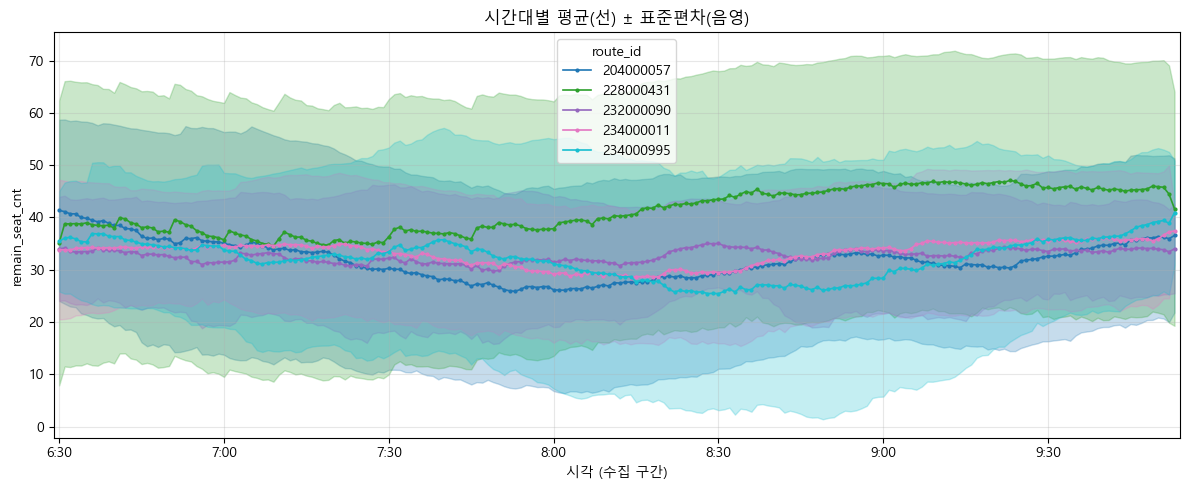

In [10]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

d = df.copy()
d["time"] = pd.to_datetime(d["time"])

# 자정 기준 분 (정수 분으로 1분 단위 버킷)
d["mins"] = d["time"].dt.hour * 60 + d["time"].dt.minute + d["time"].dt.second / 60.0
d["bucket_m"] = np.floor(d["mins"]).astype(int)

agg = (
    d.groupby(["route_id", "bucket_m"], as_index=False)["remain_seat_cnt"]
    .agg(mean="mean", var="var")
)
agg["std"] = np.sqrt(agg["var"])

fig, ax = plt.subplots(figsize=(12, 5))
routes = sorted(agg["route_id"].unique())
colors = plt.cm.tab10(np.linspace(0, 0.9, len(routes)))

for c, rid in zip(colors, routes):
    g = agg[agg["route_id"] == rid].sort_values("bucket_m")
    ax.fill_between(
        g["bucket_m"], g["mean"] - g["std"], g["mean"] + g["std"],
        color=c, alpha=0.25,
    )
    # 1분마다 점 (marker) + 선 연결
    ax.plot(
        g["bucket_m"], g["mean"],
        color=c, marker="o", markersize=2, linewidth=1.2, label=str(rid),
    )

xm, xM = int(agg["bucket_m"].min()), int(agg["bucket_m"].max())
ax.set_xlim(xm - 1, xM + 1)

def _lbl(m):
    m = int(m)
    return f"{m // 60}:{m % 60:02d}"

tick_start = (xm // 30) * 30
ticks = list(range(tick_start, xM + 1, 30))
ax.set_xticks(ticks)
ax.set_xticklabels([_lbl(t) for t in ticks])

ax.set_xlabel("시각 (수집 구간)")
ax.set_ylabel("remain_seat_cnt")
ax.legend(title="route_id", loc="best")
ax.grid(True, alpha=0.3)
plt.title("시간대별 평균(선) ± 표준편차(음영)")
plt.tight_layout()
plt.show()

In [11]:
a = df_a.copy()
a["time"] = pd.to_datetime(a["time"])
tm = a["time"].dt.floor("min")
a["bucket_m"] = tm.dt.hour * 60 + tm.dt.minute

g = (
    a.groupby("bucket_m", as_index=False)
    .agg(
        total=("remain_seat_cnt", "count"),
        zero_cnt=("remain_seat_cnt", lambda s: (s == 0).sum()),
    )
)
g["zero_rate"] = g["zero_cnt"] / g["total"]
g["시각"] = g["bucket_m"].map(lambda m: f"{m // 60:02d}:{m % 60:02d}")

best = g.sort_values(["zero_cnt", "zero_rate"], ascending=False).head(10)
best

,bucket_m,total,zero_cnt,zero_rate,시각
98,488,1058,221,0.208885,08:08
97,487,1041,217,0.208453,08:07
100,490,1047,216,0.206304,08:10
94,484,1035,209,0.201932,08:04
95,485,1043,209,0.200384,08:05
101,491,1081,207,0.191489,08:11
92,482,1018,206,0.202358,08:02
86,476,1013,204,0.201382,07:56
91,481,1022,203,0.198630,08:01
93,483,1025,202,0.197073,08:03


In [12]:
b = df_b.copy()
b["time"] = pd.to_datetime(b["time"])
tm = b["time"].dt.floor("min")
b["bucket_m"] = tm.dt.hour * 60 + tm.dt.minute

g = (
    b.groupby("bucket_m", as_index=False)
    .agg(
        total=("remain_seat_cnt", "count"),
        zero_cnt=("remain_seat_cnt", lambda s: (s == 0).sum()),
    )
)
g["zero_rate"] = g["zero_cnt"] / g["total"]
g["시각"] = g["bucket_m"].map(lambda m: f"{m // 60:02d}:{m % 60:02d}")

best = g.sort_values(["zero_cnt", "zero_rate"], ascending=False).head(10)
best

,bucket_m,total,zero_cnt,zero_rate,시각
80,470,213,13,0.061033,07:50
75,465,215,13,0.060465,07:45
76,466,215,13,0.060465,07:46
79,469,219,13,0.059361,07:49
66,456,220,13,0.059091,07:36
72,462,221,13,0.058824,07:42
74,464,224,13,0.058036,07:44
73,463,231,13,0.056277,07:43
81,471,231,13,0.056277,07:51
65,455,233,13,0.055794,07:35


In [13]:
c = df_c.copy()
c["time"] = pd.to_datetime(c["time"])
tm = c["time"].dt.floor("min")
c["bucket_m"] = tm.dt.hour * 60 + tm.dt.minute

g = (
    c.groupby("bucket_m", as_index=False)
    .agg(
        total=("remain_seat_cnt", "count"),
        zero_cnt=("remain_seat_cnt", lambda s: (s == 0).sum()),
    )
)
g["zero_rate"] = g["zero_cnt"] / g["total"]
g["시각"] = g["bucket_m"].map(lambda m: f"{m // 60:02d}:{m % 60:02d}")

best = g.sort_values(["zero_cnt", "zero_rate"], ascending=False).head(10)
best

,bucket_m,total,zero_cnt,zero_rate,시각
105,495,531,21,0.039548,08:15
106,496,528,20,0.037879,08:16
104,494,530,20,0.037736,08:14
102,492,541,19,0.035120,08:12
122,512,522,18,0.034483,08:32
100,490,541,18,0.033272,08:10
125,515,483,17,0.035197,08:35
123,513,519,17,0.032755,08:33
109,499,522,17,0.032567,08:19
103,493,538,17,0.031599,08:13


In [14]:
d = df_d.copy()
d["time"] = pd.to_datetime(d["time"])
tm = d["time"].dt.floor("min")
d["bucket_m"] = tm.dt.hour * 60 + tm.dt.minute

g = (
    d.groupby("bucket_m", as_index=False)
    .agg(
        total=("remain_seat_cnt", "count"),
        zero_cnt=("remain_seat_cnt", lambda s: (s == 0).sum()),
    )
)
g["zero_rate"] = g["zero_cnt"] / g["total"]
g["시각"] = g["bucket_m"].map(lambda m: f"{m // 60:02d}:{m % 60:02d}")

best = g.sort_values(["zero_cnt", "zero_rate"], ascending=False).head(10)
best

,bucket_m,total,zero_cnt,zero_rate,시각
65,455,477,90,0.188679,07:35
74,464,485,89,0.183505,07:44
68,458,493,89,0.180527,07:38
54,444,444,88,0.198198,07:24
75,465,483,88,0.182195,07:45
61,451,491,88,0.179226,07:31
73,463,492,87,0.176829,07:43
67,457,493,87,0.176471,07:37
59,449,440,86,0.195455,07:29
55,445,444,86,0.193694,07:25


In [15]:
e = df_b.copy()
e["time"] = pd.to_datetime(e["time"])
tm = e["time"].dt.floor("min")
e["bucket_m"] = tm.dt.hour * 60 + tm.dt.minute

g = (
    e.groupby("bucket_m", as_index=False)
    .agg(
        total=("remain_seat_cnt", "count"),
        zero_cnt=("remain_seat_cnt", lambda s: (s == 0).sum()),
    )
)
g["zero_rate"] = g["zero_cnt"] / g["total"]
g["시각"] = g["bucket_m"].map(lambda m: f"{m // 60:02d}:{m % 60:02d}")

best = g.sort_values(["zero_cnt", "zero_rate"], ascending=False).head(10)
best

,bucket_m,total,zero_cnt,zero_rate,시각
80,470,213,13,0.061033,07:50
75,465,215,13,0.060465,07:45
76,466,215,13,0.060465,07:46
79,469,219,13,0.059361,07:49
66,456,220,13,0.059091,07:36
72,462,221,13,0.058824,07:42
74,464,224,13,0.058036,07:44
73,463,231,13,0.056277,07:43
81,471,231,13,0.056277,07:51
65,455,233,13,0.055794,07:35
